# Pi Approximation Using Monte Carlo Simulation

In this notebook, we will approximate $\pi$ using a Monte Carlo simulation.

In [1]:
import random
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

from concurrent.futures import ThreadPoolExecutor
import os

Let $X$ and $Y$ be two independent random variables both drawn from the
uniform distribution in the interval $[0, 1]$.

This way, the tuple $P := (X, Y)$ can be interpreted as a random point in the
first quadrant of the carterisan plane. Say we draw $N \geq 1$ of these points
and call them $P_i = (X_i, Y_i)$, for $i \in [1, N]$.

In [2]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)

In [3]:
def draw_random_point() -> tuple[float, float]:
    """Draw a random point in the first quadrant of the Cartesian plane."""
    return (random.uniform(0, 1), random.uniform(0, 1))

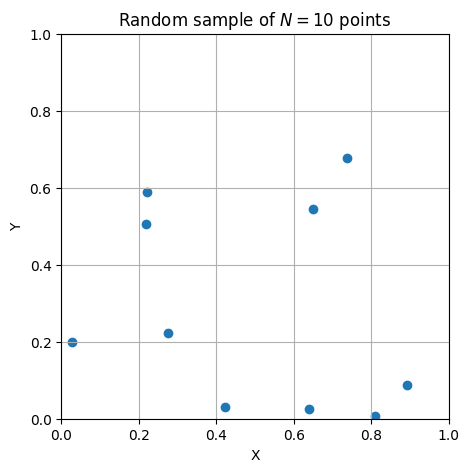

In [4]:
random_points_sample: list[tuple[int, int]] = [draw_random_point() for _ in range(10)]

fig, ax = plt.subplots(figsize=(5, 5))

for x, y in random_points_sample:
    ax.scatter(x, y, color="tab:blue")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_title(f"Random sample of $N =${len(random_points_sample)} points")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)

Now, suppose that we check whether each of these $P_i$ points falls within the
unit circle. The equation of a circle with raidus 1 centered at $(0, 0)$ is
given by:

\begin{equation*}
    x^2 + y^2 = 1
\end{equation*}

Thus, $P_i$ lies inside the unit circle if and only if $X_i^2 + Y_i^2 \leq 1$.

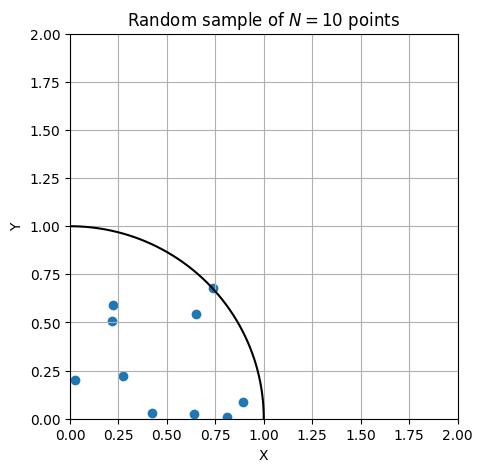

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))

theta = np.linspace(0, np.pi / 2, 200)
ax.plot(np.cos(theta), np.sin(theta), color="black", linewidth=1.5)

for x, y in random_points_sample:
    ax.scatter(x, y, color="tab:blue")

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)

ax.set_title(f"Random sample of $N =${len(random_points_sample)} points")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)

Define an indicator random variable, $H_i$, such that it takes values 1 if
$X_i^2 + Y_i^2 \leq 1$ and 0 otherwise:

\begin{equation*}
    H_i := 1[X_i^2 + Y_i^2 \leq 1]
\end{equation*}

This is a Bernoulli random variable with probability $p$, where $p$ is the
probability that the point lands inside the unit circle.

From this, we can conclude the following results, which will be useful later
on:

\begin{equation*}
    E[H_i] = p
\end{equation*}

\begin{equation*}
    \begin{align*}
        Var[H_i] &= E[H_i^2] - E[H_i]^2 \\
        &= p - p^2 \\
        &= p (1 - p)
    \end{align*}
\end{equation*}

We know that $X_i$ is drawn from $\text{Uniform}(0, 1)$. Thus, it has pdf
$f_X$ given by:

\begin{equation*}
    f_X(x_i) =
    \begin{cases}
        1 & \text{if $0 \leq x_i \leq 1$} \\
        0 & \text{otherwise}
    \end{cases}
\end{equation*}

The same is true for $Y_i$, so it has the same pdf.

Because $X_i$ and $Y_i$ are
indepedent of each other, we also have that the joint pdf
$f_{X, Y}(x_i, y_i) = f_X(x_i) f_Y(y_i)$.

Using this, we can calculate $p = P[X_i^2 + Y_i^2 \leq 1]$:

\begin{equation*}
    \begin{align*}
       p &= P[X_i^2 + Y_i^2 \leq 1] \\
       &= P[Y_i^2 \leq 1 - X_i^2] \\
       &= \int_0^1 \int_0^{\sqrt{1 - x^2}} 1 \, dy dx \\
       &= \text{Area of a quarter of the unit circle} \\
       &= \frac{\pi}{4} \\
       &\approx 0.785
    \end{align*}
\end{equation*}

Now, define another random variable, $\bar{H}_N$, as the proportion of points
that fall inside the unit circle. We can write $\bar{H}_N$ in terms of the $H_i$:

\begin{equation*}
    \bar{H}_N = \frac{1}{N} \sum_{i=1}^N H_i
\end{equation*}

We can calculate the expected value of this random variable:

\begin{equation*}
    \begin{align*}
        E[\bar{H}_N] &= E\left[\frac{1}{N} \sum_{i=1}^N H_i\right] \\
        &= \frac{1}{N} \sum_{i=1}^N E[H_i] \\
        &= \frac{1}{N} \sum_{i=1}^N p \\
        &= p \\
        &= \frac{\pi}{4}
    \end{align*}
\end{equation*}

Similarly, we can find the variace:

\begin{equation*}
    \begin{align*}
        Var[\bar{H}_N] &= Var\left[\frac{1}{N} \sum_{i=1}^N H_i\right] \\
        &= \frac{1}{N^2} \sum_{i=1}^N Var[H_i] \\
        &= \frac{1}{N^2} \sum_{i=1}^N p (1 - p) \\
        &= \frac{p (1 - p)}{N} \\
        &= \frac{1}{N} \left(\frac{\pi}{4} \left(1 - \frac{\pi}{4}\right)\right)
    \end{align*}
\end{equation*}

By the Central Limit Theorem (CLT), as $N \to \infty$, $\bar{H}_N \xrightarrow{d} \mathcal{N}(E[\bar{H}_N], Var[\bar{H}_N])$.

Thus, if draw several $\bar{H_N}$ (for sufficiently large $N$), we expect the
result to be approximately normal.

A common rule of thumb that the normal approximation is adequate when both $Np$
$N(1−p)$ are at least some threshold, typically 10 or 30 depending on who you
ask.

If we take 30, then we can use the normal approximation as long as
$N \geq \frac{30}{1 - \pi / 4} \approx 139.8$

So, as long as our $N \geq 140$, we should be able to use the normal
approximation.

Let $N = 1,000,000$ and we will sample $10,000$ $\bar{H}_N$ to visualize the
distribution.

In [19]:
N = int(1e6)
num_simulations = int(1e4)

def simulate_batch(args):
    n, batch_size = args
    rng = np.random.default_rng()
    results = np.empty(batch_size)
    for i in range(batch_size):
        X = rng.uniform(0, 1, n)
        Y = rng.uniform(0, 1, n)
        results[i] = np.mean(X**2 + Y**2 <= 1)
    return results

num_workers = os.cpu_count()
batch_size = num_simulations // num_workers

with ThreadPoolExecutor(max_workers=num_workers) as executor:
    batches = list(executor.map(simulate_batch, [(N, batch_size)] * num_workers))

simulated_H_bar_1M = np.concatenate(batches)

In [20]:
N = int(1e5)

with ThreadPoolExecutor(max_workers=num_workers) as executor:
    batches = list(executor.map(simulate_batch, [(N, batch_size)] * num_workers))

simulated_H_bar_100k = np.concatenate(batches)

In [21]:
N = int(1e4)

with ThreadPoolExecutor(max_workers=num_workers) as executor:
    batches = list(executor.map(simulate_batch, [(N, batch_size)] * num_workers))

simulated_H_bar_10k = np.concatenate(batches)

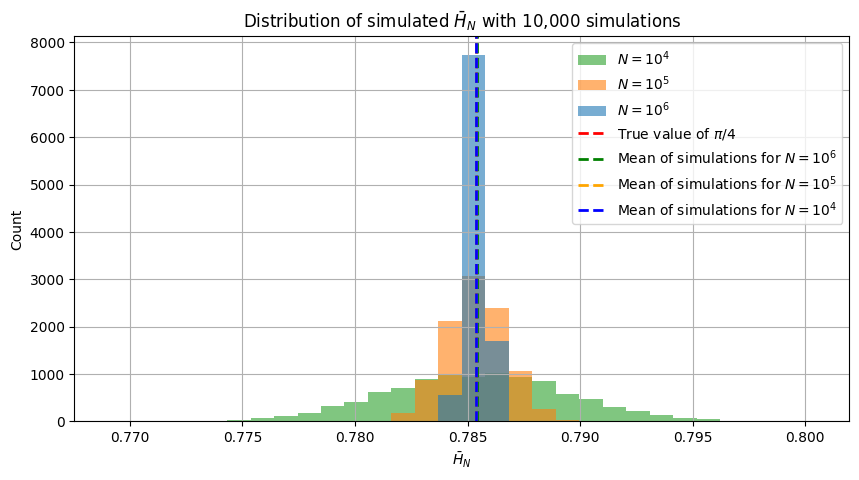

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

_, bins, _ = ax.hist(simulated_H_bar_10k, bins=30, density=False, alpha=0.6, color="tab:green", label="$N=10^4$")
ax.hist(simulated_H_bar_100k, bins=bins, density=False, alpha=0.6, color="tab:orange", label="$N=10^5$")
ax.hist(simulated_H_bar_1M, bins=bins, density=False, alpha=0.6, color="tab:blue", label="$N=10^6$")

ax.axvline(np.pi / 4, color="red", linestyle="dashed", linewidth=2, label="True value of $\\pi/4$")


ax.axvline(np.mean(simulated_H_bar_1M), color="green", linestyle="dashed", linewidth=2, label="Mean of simulations for $N=10^6$")
ax.axvline(np.mean(simulated_H_bar_100k), color="orange", linestyle="dashed", linewidth=2, label="Mean of simulations for $N=10^5$")
ax.axvline(np.mean(simulated_H_bar_10k), color="blue", linestyle="dashed", linewidth=2, label="Mean of simulations for $N=10^4$")

ax.set_title(f"Distribution of simulated $\\bar{{H}}_{{N}}$ with {num_simulations:,} simulations")
ax.set_xlabel("$\\bar{H}_N$")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True)

We can more formally confirm what the plot above shows by using a z-test.

By the CLT, $\bar{H}_N$ is approximately normally distributed with mean $p$
variance $p(1−p)/N$.

Since $H_i$​ is Bernoulli, the variance is fully determined by $p$, so testing
the mean is sufficient. We have the following hypothesis testing problem:

\begin{equation*}
    \begin{cases}
        H_0: p = \frac{\pi}{4} \\
        H_1: p \neq \frac{\pi}{4}
    \end{cases}
\end{equation*}

Under $H_0$, we have

\begin{equation*}
    Z := \frac{\bar{H}_N - \frac{\pi}{4}}{\frac{1}{N} \frac{\pi}{4} (1 - \frac{\pi}{4})} \sim \mathcal{N}(0, 1)
\end{equation*}

Say that we 